In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('../data/raw/fitness_dataset.csv')
df[['smokes']].head()


,smokes
0,no
1,0
2,0
3,0
4,yes


In [4]:
# Step 1: Inspect the inconsistency
print("Unique raw values in 'smokes':", df['smokes'].unique())
print()
print(df['smokes'].value_counts(dropna=False))


Unique raw values in 'smokes': ['no' '0' 'yes' '1']

smokes
yes    711
0      581
no     518
1      190
Name: count, dtype: int64


As expected, `smokes` currently holds four distinct raw values that
really only represent two categories: **smoker** and **non-smoker**.

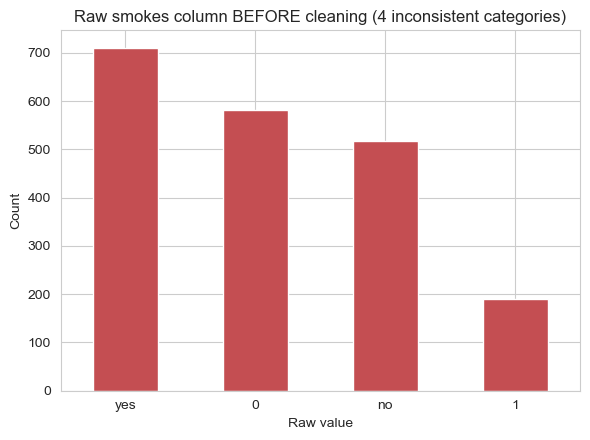

In [5]:
fig, ax = plt.subplots(figsize=(6,4.5))
df['smokes'].astype(str).value_counts().plot(kind='bar', color='#C44E52', ax=ax)
ax.set_title('Raw smokes column BEFORE cleaning (4 inconsistent categories)')
ax.set_xlabel('Raw value')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [8]:
# Step 2: Clean/standardize the column into a single consistent binary representation
smokes_map = {
    '0': 0, 0: 0, 'no': 0, 'No': 0, 'NO': 0,
    '1': 1, 1: 1, 'yes': 1, 'Yes': 1, 'YES': 1,
}

df_clean = df.copy()
df_clean['smokes_clean'] = (
    df_clean['smokes'].astype(str).str.strip().str.lower().map({'0': 0, '1': 1, 'no': 0, 'yes': 1})
)

print("Any unmapped / unexpected values left?", df_clean['smokes_clean'].isna().sum())
df_clean['smokes_clean'] = df_clean['smokes_clean'].astype(int)

# Also provide a readable label version for plotting / reporting
df_clean['smoking_status'] = df_clean['smokes_clean'].map({0: 'Non-smoker', 1: 'Smoker'})
df_clean[['smokes', 'smokes_clean', 'smoking_status']].drop_duplicates().sort_values('smokes')


Any unmapped / unexpected values left? 0


,smokes,smokes_clean,smoking_status
1,0,0,Non-smoker
22,1,1,Smoker
0,no,0,Non-smoker
4,yes,1,Smoker


### EDA Visualization — Smoking status AFTER cleaning

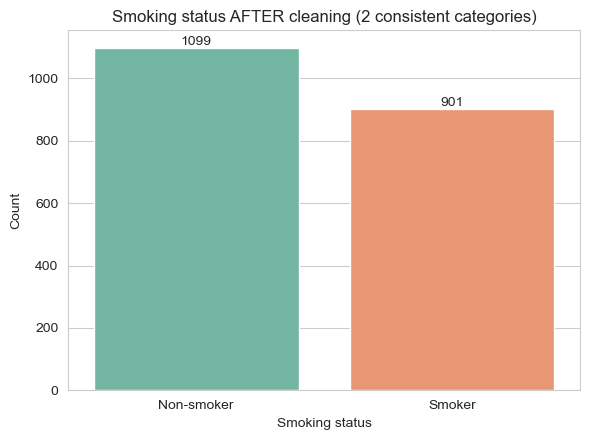

In [8]:
fig, ax = plt.subplots(figsize=(6,4.5))
sns.countplot(data=df_clean, x='smoking_status', hue='smoking_status',
              order=['Non-smoker', 'Smoker'], palette='Set2', legend=False, ax=ax)
ax.set_title('Smoking status AFTER cleaning (2 consistent categories)')
ax.set_xlabel('Smoking status')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/member2_smoking_status_barchart.png', dpi=110, bbox_inches='tight')
plt.show()


In [9]:
df_clean.to_csv('../results/outputs/member2_smokes_cleaned.csv', index=False)
print("Saved cleaned output to results/outputs/member2_smokes_cleaned.csv")


Saved cleaned output to results/outputs/member2_smokes_cleaned.csv
